# 14. Capacity Expansion III — Sector-Coupled Sizing (Electrolyzer)

Models 12 and 13 applied capacity expansion only to generation and storage on the electricity side.
This model applies the same mechanic to a **sector-coupling link** — letting the solver decide how
big to build the electrolyzer, given a fixed renewable fleet and a fixed hydrogen offtake contract.

The objective is to model a system with a fixed 10 MW Solar PV + 15 MW Wind fleet, a fixed electrical
load, a fixed constant hydrogen demand, and a hydrogen storage buffer — but with the electrolyzer's
capacity left as a free variable. This is a genuinely different sizing question from Models 12-13:
the electrolyzer's economics depend on the hydrogen offtake price and the cost of the electricity
feeding it, not on its own weather-driven output the way solar or wind capacity does.

## Why the electrolyzer's optimal size is a trade-off, not a maximization
A bigger electrolyzer can capture cheaper, more intermittent renewable electricity (running only in
the best-priced hours) and lean less on grid import — but it also costs more in annualized capital
whether it runs or not. Whether building it is worth it at all depends on the spread between the
contracted hydrogen sale price and the cost of the electricity feeding it. Unlike solar or wind
capacity (Models 12-13), which face diminishing returns as more panels or turbines increasingly
compete for the same handful of good-weather hours, the electrolyzer's marginal profitability per MW
is roughly constant across its whole size range here, since neither the hydrogen sale price nor grid
electricity availability changes with volume. That difference in economic shape is worth watching for
in the results below.

## System Topology
1. **Bus:** `electricity_bus` and `hydrogen_bus`.
2. **Generators (Source):** Solar PV (10 MW, fixed) and Wind (15 MW, fixed).
3. **Generators (Grid, two-directional):** `Grid_Import` and `Grid_Export`, fixed capacity.
4. **Loads:** the day/night industrial electrical load, and a constant hydrogen offtake demand.
5. **Links:** `Electrolyzer` — now `p_nom_extendable=True`, with an annualized `capital_cost` and a
   `p_nom_max` representing the maximum electrolyzer size the site could physically accommodate.
6. **Storage:** `Hydrogen_Storage`, fixed capacity, buffering the mismatch between intermittent
   electrolyzer output and the flat offtake — unchanged in mechanism from Model 08, but now sized
   independently of whatever electrolyzer capacity the solver chooses.


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from utils.viz_utils import set_nature_style
set_nature_style()

df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## Technical Parameters

Solar, wind, grid, and demand parameters are fixed inputs, unchanged in style from earlier models.
Only the electrolyzer gains `p_nom_extendable`-style treatment: an annualized `capital_cost` and a
`p_nom_max` site limit, alongside its existing conversion efficiency.


In [2]:
DISCOUNT_RATE = 0.04

def annuity(lifetime_years, investment, fom_percent):
    r = DISCOUNT_RATE
    crf = (r * (1 + r) ** lifetime_years) / ((1 + r) ** lifetime_years - 1)
    return investment * (crf + fom_percent / 100.0)

tech_param = {
    'solar_pv': {'p_nom': 10.0, 'marginal_cost': 0.0},
    'wind': {'p_nom': 15.0, 'marginal_cost': 0.0},
    'market_grid': {'import_p_nom': 20.0, 'export_p_nom': 18.0},
    'demand': {'day_load_mw': 8.0, 'night_load_mw': 4.0},
    'electrolyzer': {
        'p_nom_max': 10.0,                          # Max site-feasible electrolyzer size, MW
        'capital_cost': annuity(20, 900_000, 4.0),   # EUR/MW/year
        'efficiency': 0.65,
        'marginal_cost': 0.0
    },
    'hydrogen_storage': {
        'e_nom': 20.0,      # Fixed, unlike the electrolyzer
        'standing_loss': 0.0
    },
    'h2_demand': {
        'avg_mw': 1.5,
        'sale_price_eur_per_mwh': 100.0   # Value of hydrogen delivered against the offtake contract
    }
}

print(f"Electrolyzer annualized capital cost: EUR {tech_param['electrolyzer']['capital_cost']:,.0f} / MW / year")


Electrolyzer annualized capital cost: EUR 102,224 / MW / year


## Initializing the Network

Two buses: `electricity_bus` and `hydrogen_bus`, as in Model 08.


In [3]:
n = pypsa.Network()
n.set_snapshots(df_pv.index)
n.add("Bus", "electricity_bus")
n.add("Bus", "hydrogen_bus")


Index(['hydrogen_bus'], dtype='object')

## Adding Generators and the Grid Connection

Solar, Wind, `Grid_Import`, and `Grid_Export` are all fixed-capacity, unchanged from earlier models.


In [4]:
n.add("Generator", "Solar_PV", bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'], p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

n.add("Generator", "Wind", bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'], p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

n.add("Generator", "Grid_Import", bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'], marginal_cost=df_price['price'])

n.add("Generator", "Grid_Export", bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0, p_max_pu=0.0, marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## Adding the Electrical and Hydrogen Demands

The industrial electrical load, as in earlier models. The hydrogen demand is modeled here as a
**market sale** rather than a hard `Load` — a negative generator selling hydrogen at a fixed
contracted price, the same sink pattern used for `Grid_Export`. This matters for the sizing decision:
with a hard `Load`, the model would be forced to always meet the full demand regardless of cost,
which would make the electrolyzer's size a feasibility question rather than a genuine economic
trade-off. Framing it as a sale instead lets the solver weigh whether producing hydrogen is worth it
in each hour, which is what actually determines the electrolyzer's optimal capacity.


In [5]:
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
electrical_load = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
electrical_load = pd.Series(electrical_load, index=n.snapshots)
n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=electrical_load)

n.add("Generator", "H2_Market", bus="hydrogen_bus",
      p_nom=10.0, p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=tech_param['h2_demand']['sale_price_eur_per_mwh'])


Index(['H2_Market'], dtype='object')

## Adding the Electrolyzer and Hydrogen Storage

`Electrolyzer` is now `p_nom_extendable=True`, exactly like `Solar_PV` and `Wind` in Models 12-13 -
the same mechanic, just applied to a `Link` instead of a `Generator`. `Hydrogen_Storage` stays at a
fixed size, so the storage buffer doesn't grow or shrink automatically alongside whatever
electrolyzer capacity the solver chooses.


In [6]:
n.add("Link", "Electrolyzer",
      bus0="electricity_bus", bus1="hydrogen_bus",
      p_nom_extendable=True,
      p_nom_max=tech_param['electrolyzer']['p_nom_max'],
      efficiency=tech_param['electrolyzer']['efficiency'],
      capital_cost=tech_param['electrolyzer']['capital_cost'],
      marginal_cost=tech_param['electrolyzer']['marginal_cost'])

n.add("Store", "Hydrogen_Storage", bus="hydrogen_bus",
      e_nom=tech_param['hydrogen_storage']['e_nom'], e_cyclic=True,
      standing_loss=tech_param['hydrogen_storage']['standing_loss'])


Index(['Hydrogen_Storage'], dtype='object')

## Running the Optimization

The solver now jointly decides the electrolyzer's capacity and its hour-by-hour dispatch across the
full year, alongside how much hydrogen is actually worth producing and selling at the contracted
price.


In [7]:
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Annualized Capital + Net Operating Cost): EUR {n.objective:,.2f}")


Index(['electricity_bus', 'hydrogen_bus'], dtype='object', name='Bus')
Index(['Hydrogen_Storage'], dtype='object', name='Store')
Index(['Electrolyzer'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 19.41it/s]
INFO:linopy.io: Writing time: 1.39s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 70081 primals, 148922 duals
Objective: -1.30e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.


Solver Status: ok
Total Objective Value (Annualized Capital + Net Operating Cost): EUR -1,298,609.85


## Analyzing the Results

We check where the chosen capacity landed relative to `p_nom_max`. If it sits exactly at the limit,
that's informative in its own right: it means every added MW up to the limit was still profitable,
and the site constraint — not the economics — is what capped the answer. That's a meaningfully
different outcome from Models 12-13's solar and wind results, where the optimal capacities landed
strictly inside their own limits.


Optimal Electrolyzer Capacity: 10.00 MW  (limit: 10.0 MW)
Electrolyzer Annualized CAPEX: EUR 1,022,235.75 / year
--------------------------------------------------
Hydrogen Produced:             17,608.50 MWh
Hours Electrolyzer Active:     2709 / 8760
Electrolyzer Capacity Factor:  30.9%


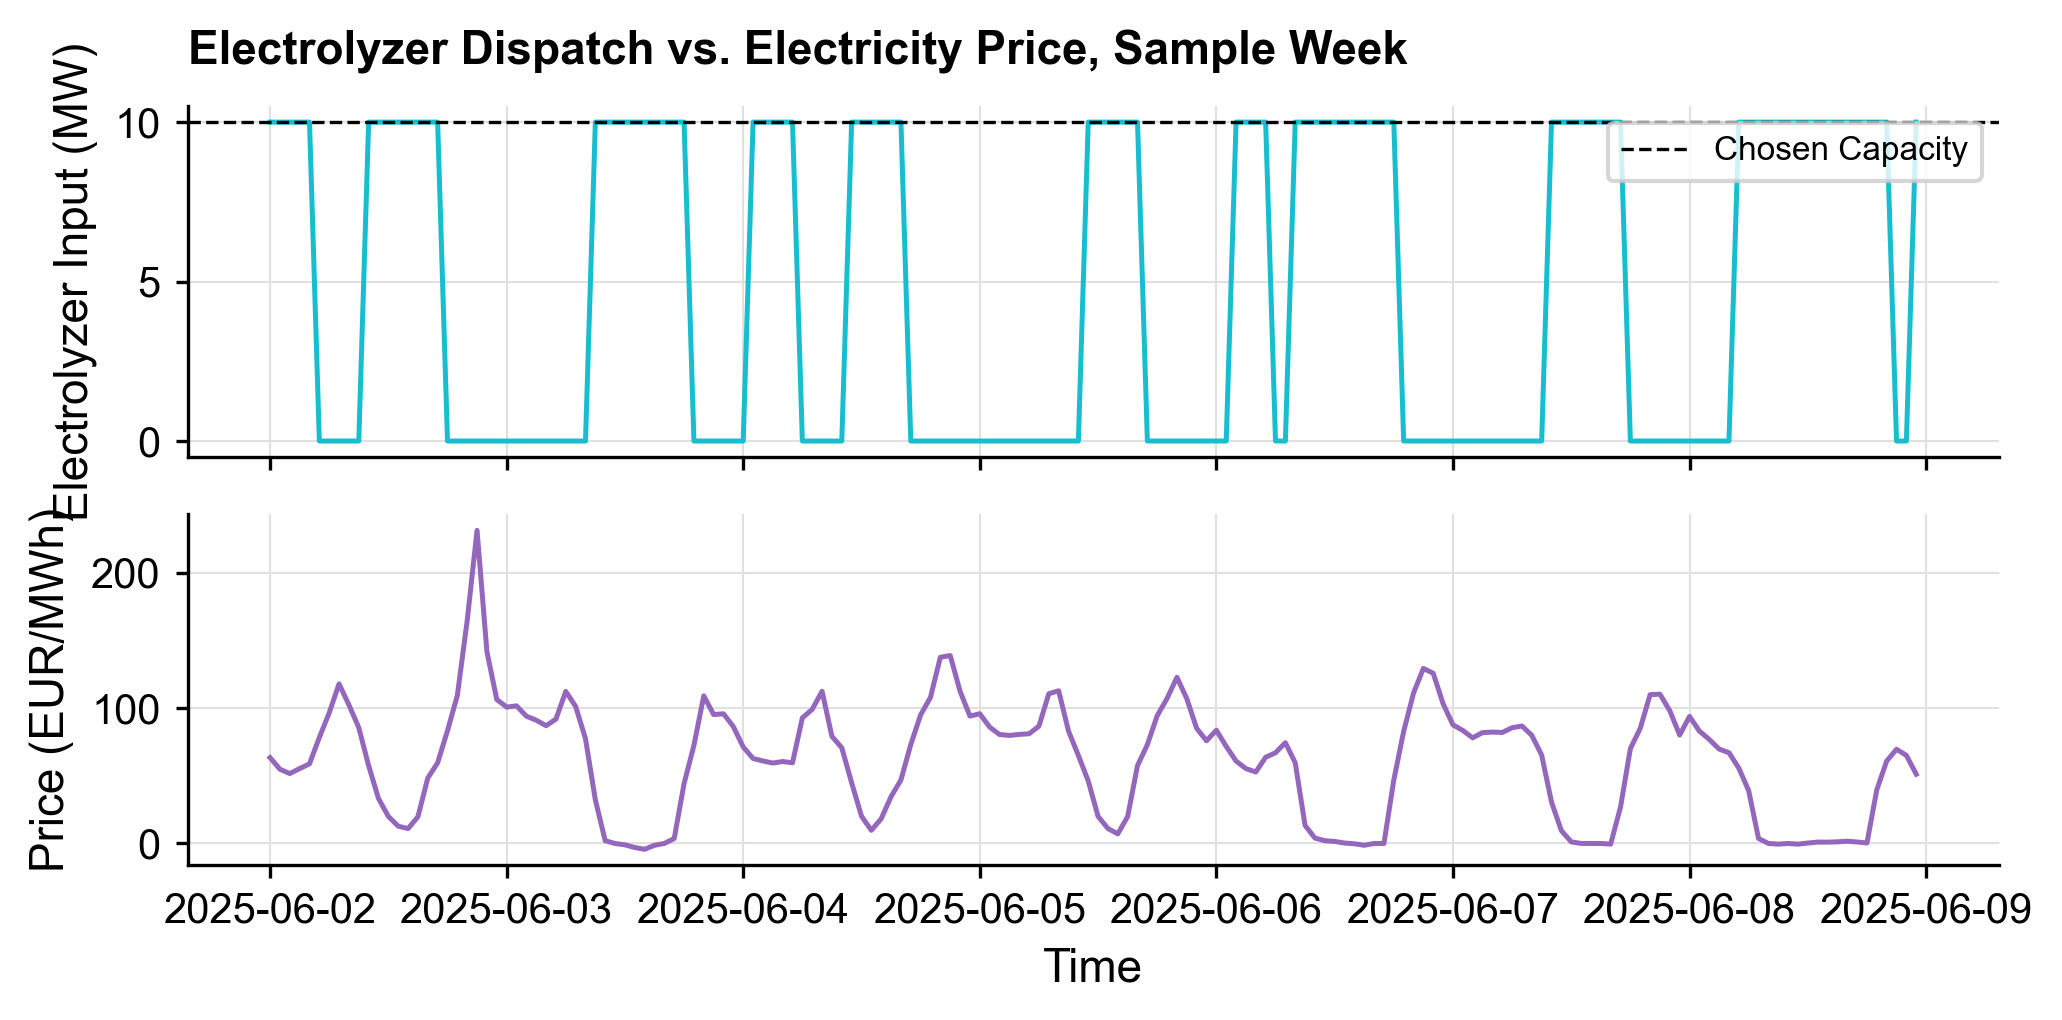

In [8]:
optimal_electrolyzer_mw = n.links.at['Electrolyzer', 'p_nom_opt']
electrolyzer_capex = optimal_electrolyzer_mw * tech_param['electrolyzer']['capital_cost']

h2_produced_mwh = -n.links_t.p1['Electrolyzer'].sum()
h2_sold_mwh = -n.generators_t.p['H2_Market'].sum()
electrolyzer_input_mwh = n.links_t.p0['Electrolyzer'].sum()

hours_active = (n.links_t.p0['Electrolyzer'] > 0.01).sum()
capacity_factor = electrolyzer_input_mwh / (optimal_electrolyzer_mw * len(n.snapshots)) if optimal_electrolyzer_mw > 0 else 0

print(f"Optimal Electrolyzer Capacity: {optimal_electrolyzer_mw:,.2f} MW  (limit: {tech_param['electrolyzer']['p_nom_max']:.1f} MW)")
print(f"Electrolyzer Annualized CAPEX: EUR {electrolyzer_capex:,.2f} / year")
print("-" * 50)
print(f"Hydrogen Produced:             {h2_produced_mwh:,.2f} MWh")
print(f"Hours Electrolyzer Active:     {hours_active} / {len(n.snapshots)}")
print(f"Electrolyzer Capacity Factor:  {100*capacity_factor:.1f}%")

# Plot: electrolyzer dispatch against electricity price, sample week - shows which hours it targets
week = (n.snapshots >= '2025-06-02') & (n.snapshots < '2025-06-09')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(n.snapshots[week], n.links_t.p0['Electrolyzer'][week], color='#17becf', linewidth=1.2)
ax1.axhline(optimal_electrolyzer_mw, color='black', linestyle='--', linewidth=0.8, label='Chosen Capacity')
ax1.set_ylabel('Electrolyzer Input (MW)')
ax1.set_title('Electrolyzer Dispatch vs. Electricity Price, Sample Week', pad=10, loc='left', fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)

ax2.plot(n.snapshots[week], df_price['price'][week], color='#9467bd', linewidth=1.2)
ax2.set_ylabel('Price (EUR/MWh)')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()
